# 非线性动力

- 变量之间不是加减关系。

常标识为：
$$\frac{dx}{dt} = f(x,t,\mu)$$
- x：状态变量
- t：时间
- μ：参数. 外部条件

常见：
- 单摆

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

非线性动力系统随着参数的变化，会产生混沌现象：即使方程确定，改变初始值最终结果会发生巨大变化，即不可预测

## 蝴蝶效应：洛伦兹系统
- $\sigma$ 普朗特数, 流体力学一个参数。常取值10
- $\rho$ 雷利数, 系统内外温差，驱动力。$\rho$取值28时，系统出现混沌现象。
- $\beta$ 流层物理尺寸。常取值8/3
- $x,y,z$：状态变量. 表示天气

$$
\begin{cases}
\frac{dx}{dt} = \sigma(y-x) \\
\frac{dy}{dt} = x(\rho-z) - y \\
\frac{dz}{dt} = xy - \beta z
\end{cases}
$$

In [11]:
def lorenz_system(t, state, sigma, rho, beta):
    """ 定义方程组, 任一时刻 """
    x, y, z = state
    # 这里的变量相乘 (x*z, x*y) 就是非线性的来源
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z
    return [dxdt, dydt, dzdt]

# 3. 求解微分方程 (Numerical Integration)
def get_result(
    params= (10.0, 10.0, 8/3.0), # 参数
    initial_state = [1.0, 1.0, 1.0], # 初始状态
    t_span = (0, 50), # 模拟时间范围（0到50秒）
    ):
    t_eval = np.linspace(t_span[0], t_span[1], 10000) # 1万个点求解
    solution = solve_ivp(
        lorenz_system, 
        t_span, 
        initial_state, 
        args=params, 
        t_eval=t_eval,
        method='RK45' # 使用自适应步长的龙格-库塔法
    )
    x, y, z = solution.y
    return x,y,z

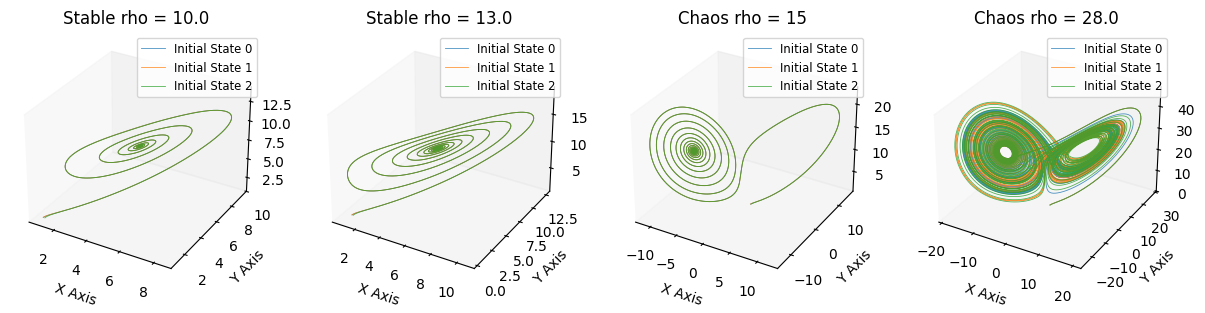

In [50]:
initial_states = [
    [1.0, 1.0, 1.0],
    [1.0, 1.0, 1.01],  # 稍微改变 Z 轴起始点
    [1.1, 1.0, 1.0]   # 稍微改变 X 轴起始点
]
rho_values = [10.0, 13.0, 15, 28.0]
titles = [f'Stable rho = {rho}' if rho < 13.9 else f'Chaos rho = {rho}'  for rho in rho_values]
fig, axes = plt.subplots(1, len(rho_values), subplot_kw={'projection': '3d'}, figsize=(15,8))
for r,title, ax in zip(rho_values,titles, axes):
    for i, istate in enumerate(initial_states):
        data = get_result(params=(10.0, r, 8/3.0), initial_state=istate)
        ax.plot(data[0], data[1], data[2], lw=0.6, label=f'Initial State {i}', alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel("X Axis")
    ax.set_ylabel("Y Axis")
    ax.grid(False)
    ax.legend(loc='upper right', fontsize='small')

可以看到，对于$\rho=28$的混沌系统，初始值的微小变化会导致系统状态的巨大变化，最终结果不可预测。

## 单摆
理想单摆是周期固定的。
$$\frac{d^2\theta}{dt^2} + \frac{g}{l} \sin\theta = 0$$
- $\theta$：摆角.  $\sin\theta$ 非线性
- $\frac{g}{l}$：系统参数，重力加速度与摆长的比值
现实单摆有阻力和外部驱动力，周期不恒定。
$$\frac{d^2\theta}{dt^2} + \gamma \frac{d\theta}{dt} + \frac{g}{l} \sin\theta = A \cos(\omega t)$$
- $\gamma$：阻尼系数，表示摩擦力大小
- $A$：外部驱动力幅值
- $\omega$：外部驱动力频率

当外部驱动力足够强时，单摆系统也会出现混沌现象。

`solve_ivp`函数规定形式 为 $\frac{dy}{dt} = f(t,y)$，因此需要将二阶方程转化为一阶方程组。
令 $w = \frac{d\theta}{dt}$，则有：
$$\begin{cases}
\frac{d\theta}{dt} = w \\
\frac{dw}{dt} = -\gamma w - \frac{g}{l} \sin\theta + A \cos(\omega t)
\end{cases}$$


In [9]:
def pendulum(t, state, A, w_drive=1, g=9.8, L=1.0, gamma=0.5):
    """ 单摆方程 """
    theta, omega = state # 角度和角速度
    d_theta = omega
    d_omega = -(g/L) * np.sin(theta) - gamma * omega + A * np.cos(w_drive * t)
    return [d_theta, d_omega]

In [10]:
def get_result(
    A,                        # 参数 A（推力强度）
    initial_state=[0.1, 0.0], # 初始状态 [角度, 角速度]
    t_span=(0, 200),           # 时间范围
    w_drive=0.67, g=9.8, L=9.8, gamma=0.1 # 其他固定参数
    ):
    t_eval = np.linspace(t_span[0], t_span[1], 10000)
    
    sol = solve_ivp(
        pendulum, 
        t_span, 
        initial_state, 
        args=(A, w_drive, g, L, gamma), 
        t_eval=t_eval,
        method='RK45'
    )
    return sol.t, sol.y  # 返回时间点和对应的 [theta, omega]

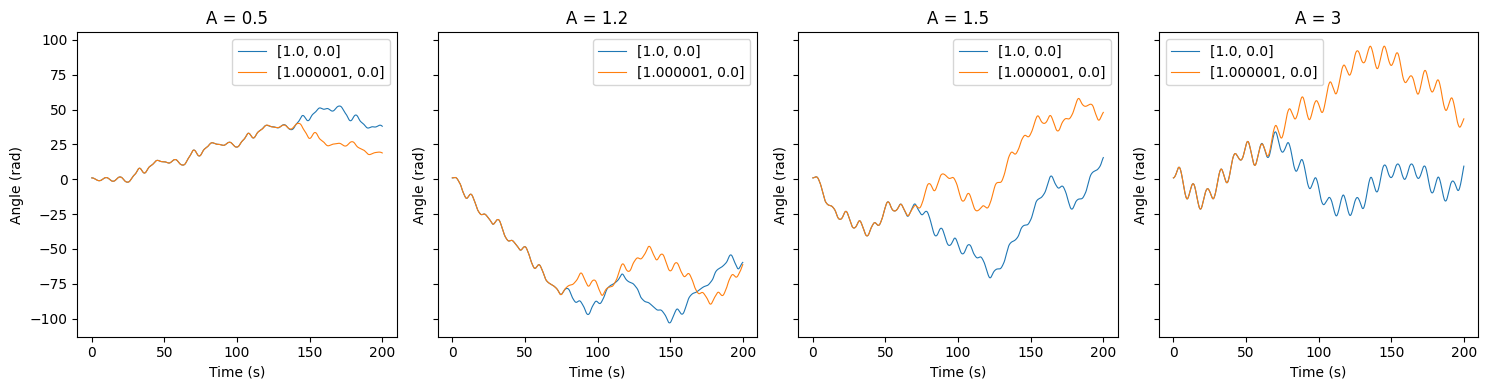

In [16]:
A_values = [0.5, 1.2, 1.5,3]
initial_states = [
    [1.0, 0.0],
    [1.000001, 0.0]
]
fig, axes = plt.subplots(1, len(A_values), figsize=(15,4), sharey=True)

for A, ax in zip(A_values, axes):
    for istate in initial_states:
        t, y = get_result(A=A,initial_state=istate)
        ax.plot(t, y[0], lw=0.8, label=f'{istate}')
    ax.set_title(f"A = {A}")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")
    ax.legend()
fig.tight_layout()

## Logistic Map
- 描述金融市场、人口增长、生态系统等的离散时间动力系统。
$$x_{n+1} = r x_n (1 - x_n)$$
- $x_n$：系统状态，通常表示种群比例或市场份额
- $r$：增长率，系统参数

**金融**

今年如果市场涨得好，会跟风，明年继续涨；但是如果涨得太高，就可会崩盘。即当 $r$ 增大时，系统会经历从稳定状态到周期性振荡，最终进入混沌状态的转变。

In [30]:
def market(r, x0, steps=200):
    """ 方程 """
    x = np.zeros(steps)
    x[0] = x0
    for t in range(1, steps):
        x[t] = r* x[t-1] * (1-x[t-1])
    return x

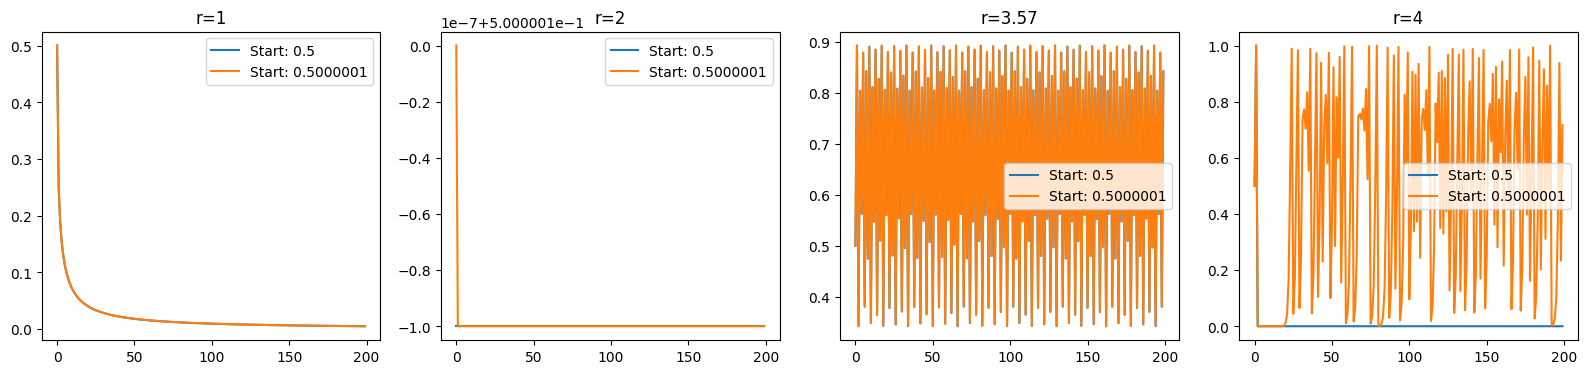

In [31]:
rs = [1, 2, 3.57, 4]
x0s = [0.5, 0.5000001]

fig, axes = plt.subplots(1, len(rs), figsize=(16,4))
for r, ax in zip(rs, axes):
    for x0 in x0s:
        res = market(r=r, x0=x0)
        ax.plot(res, label=f'Start: {x0}') 
    ax.set_title(f'r={r}')
    ax.legend()

fig.tight_layout()

吸引子：不论初始状态如何，经过足够长时间到达一个特定行为。
- 点吸引子：系统状态趋向一个固定点
- 周期吸引子：系统状态在一个周期内循环。而不是一个点
- 奇异吸引子(混沌)：系统状态在一个复杂的轨迹上运动，既不趋向一个点，也不周期循环。具有**分形结构**和敏感依赖初始条件的特征。
  - 有界性：
  - 非周期性：


## 分形几何

分形：局部是整体的缩影。将物体放大，局部和整体一模一样。分形维数：非整数维度，描述分形的复杂程度。
  
比如对一条线，不断地折叠重复，最终形成一个分形曲线。但又没有充满平面。所以维数是1和2之间地分数。

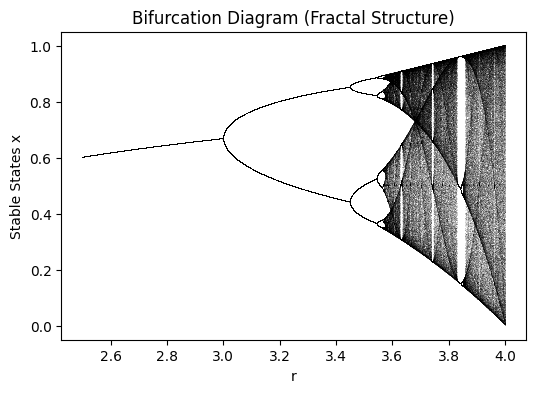

In [37]:
import numpy as np
import matplotlib.pyplot as plt

def plot_bifurcation():
    n = 10000  # r 的精度
    r = np.linspace(2.5, 4.0, n)
    iterations = 1000  # 总迭代次数
    last = 100        # 只画最后 100 次，代表长期稳定状态
    
    x = 1e-5 * np.ones(n) # 初始值
    
    plt.figure(figsize=(6, 4))
    for i in range(iterations):
        x = r * x * (1 - x) # 核心迭代公式
        if i >= (iterations - last):
            plt.plot(r, x, ',k', alpha=0.1) # 用极小的点绘制

    plt.title("Bifurcation Diagram (Fractal Structure)")
    plt.xlabel("r")
    plt.ylabel("Stable States x")
    plt.show()

plot_bifurcation()


- 单线区 ($r < 3$)：系统很“听话”，最终都会收敛到唯一的不动点。
- 分叉区 ($3 < r < 3.57$)：系统开始“纠结”，在 2、4、8... 个点之间循环。这就是周期倍增。
- 混沌区 ($r > 3.57$)：系统彻底“放飞”，稳定状态不再是几个点，而是一个分形集合。